<a href="https://colab.research.google.com/github/tainzoe9/IAPRACTICAS/blob/main/25_UNAM_AI_Actividad_Laboratorio_4_6_cancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center>

$\Huge \textbf{Universidad Nacional Autónoma de México}$  
$\Huge \textbf{Facultad de Ciencias}$  
<p align="center">
  <img src="https://www.icat.unam.mx/wp-content/uploads/2021/11/Copia-de-LogoUNAM.-Azul.-Fondo-transparente.png" alt="UNAM" width="200"/>
</p>

<hr style="height:3px; background-color:#0B6E4F; border:none;"/>


$\LARGE \textbf{Inteligencia Artificial}$  

$\Large \textit{Laboratorio 2.3}$  


\begin{array}{rl}
\textbf{Docente:} & Dra. Jessica Sarahi Méndez Rincón \\[6pt]
\textbf{Ayudante de laboratorio:} & Diego Eduardo Peña Villegas \\[6pt]
\textbf{Alumno:} & Sita Zoe Sotomayor Carrillo \\[6pt]
\textbf{Fecha de realización:} & 25/04/2026
\end{array}

</center>

#Cáncer de seno

Divide aleatoriamente la base de datos de cáncer de seno de Wisconsin 3 en un conjunto de entrenamiento con el 70% de los datos y un conjunto de validacióon con el 30% restante. Esta base de datos contiene 699 registros de tumores de seno, de los cuales 458 son benignos y 241 son malignos. Cada registro consta de los siguientes atributos: código muestra grosor Uniformidad del tamaño de la célula Uniformidad de la forma de la célula Adhesión marginal Tamaño de la célula epitelial Núcleos desnudos Cromatina blanda Núcleolos Normales Mitosis de Células Clase Entrena al menos 2 clasificadores de tumores de seno usando distintas distribuciones. Evaluá los clasificadores entrenados tanto con el conjunto de entrenamiento como con el conjunto de validación y discute su desempeño. Existen 16 registros en la base de datos con un atributo no especicado. Investiga estrategias para rellenar los datos faltantes, utiliza las que consideres más adecuadas para este problema y discute el impacto en el desempeño del clasificador

In [ ]:
################LIBRERIAS A UTILIZAR
# Importacion de librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, f1_score

In [ ]:


# Carga de datos (asumiendo formato estándar de UCI)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/breast-cancer-wisconsin.data"
columns = ['id', 'clump_thickness', 'unif_cell_size', 'unif_cell_shape', 'marg_adhesion',
           'single_epith_size', 'bare_nuclei', 'bland_chromatin', 'norm_nucleoli', 'mitoses', 'class']
df = pd.read_csv(url, names=columns)

# Manejo de datos faltantes
# Los datos faltantes vienen como '?' en esta base de datos
df.replace('?', np.nan, inplace=True)
df['bare_nuclei'] = pd.to_numeric(df['bare_nuclei'])
df['bare_nuclei'] = df['bare_nuclei'].fillna(df['bare_nuclei'].median())


# Ajuste de etiquetas: 2 (benigno) -> 0, 4 (maligno) -> 1
df['class'] = df['class'].map({2: 0, 4: 1})

# División 70/30
X = df.drop(['id', 'class'], axis=1)
y = df['class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

In [ ]:
df.head(5)

,id,clump_thickness,unif_cell_size,unif_cell_shape,marg_adhesion,single_epith_size,bare_nuclei,bland_chromatin,norm_nucleoli,mitoses,class
0,1000025,5,1,1,1,2,1.0,3,1,1,0
1,1002945,5,4,4,5,7,10.0,3,2,1,0
2,1015425,3,1,1,1,2,2.0,3,1,1,0
3,1016277,6,8,8,1,3,4.0,3,7,1,0
4,1017023,4,1,1,3,2,1.0,3,1,1,0


#2. Entrenamiento de Clasificadores
Entrenaremos tres variantes basadas en árboles para comparar la evolución desde un modelo simple hasta uno de ensamble por boosting.

In [ ]:
# 1. Árbol de Decisión Simple
dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_model.fit(X_train, y_train)

# 2. Random Forest (Bagging)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 3. XGBoost (Boosting)
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:00:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

## Evaluación de Modelos

### Árbol de Decisión Simple

In [ ]:
# Predicciones en conjunto de entrenamiento
y_train_pred_dt = dt_model.predict(X_train)

# Predicciones en conjunto de prueba
y_test_pred_dt = dt_model.predict(X_test)

print("--- Árbol de Decisión Simple ---")
print("\nAccuracy en entrenamiento:", accuracy_score(y_train, y_train_pred_dt))
print("Classification Report en entrenamiento:\n", classification_report(y_train, y_train_pred_dt))
print("Confusion Matrix en entrenamiento:\n", confusion_matrix(y_train, y_train_pred_dt))

print("\nAccuracy en prueba:", accuracy_score(y_test, y_test_pred_dt))
print("Classification Report en prueba:\n", classification_report(y_test, y_test_pred_dt))
print("Confusion Matrix en prueba:\n", confusion_matrix(y_test, y_test_pred_dt))

--- Árbol de Decisión Simple ---

Accuracy en entrenamiento: 0.9713701431492843
Classification Report en entrenamiento:
               precision    recall  f1-score   support

           0       1.00      0.96      0.98       320
           1       0.93      0.99      0.96       169

    accuracy                           0.97       489
   macro avg       0.96      0.98      0.97       489
weighted avg       0.97      0.97      0.97       489

Confusion Matrix en entrenamiento:
 [[307  13]
 [  1 168]]

Accuracy en prueba: 0.9380952380952381
Classification Report en prueba:
               precision    recall  f1-score   support

           0       0.99      0.91      0.95       138
           1       0.86      0.99      0.92        72

    accuracy                           0.94       210
   macro avg       0.92      0.95      0.93       210
weighted avg       0.95      0.94      0.94       210

Confusion Matrix en prueba:
 [[126  12]
 [  1  71]]


### Random Forest

In [ ]:
# Predicciones en conjunto de entrenamiento
y_train_pred_rf = rf_model.predict(X_train)

# Predicciones en conjunto de prueba
y_test_pred_rf = rf_model.predict(X_test)

print("--- Random Forest ---")
print("\nAccuracy en entrenamiento:", accuracy_score(y_train, y_train_pred_rf))
print("Classification Report en entrenamiento:\n", classification_report(y_train, y_train_pred_rf))
print("Confusion Matrix en entrenamiento:\n", confusion_matrix(y_train, y_train_pred_rf))

print("\nAccuracy en prueba:", accuracy_score(y_test, y_test_pred_rf))
print("Classification Report en prueba:\n", classification_report(y_test, y_test_pred_rf))
print("Confusion Matrix en prueba:\n", confusion_matrix(y_test, y_test_pred_rf))

--- Random Forest ---

Accuracy en entrenamiento: 1.0
Classification Report en entrenamiento:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       320
           1       1.00      1.00      1.00       169

    accuracy                           1.00       489
   macro avg       1.00      1.00      1.00       489
weighted avg       1.00      1.00      1.00       489

Confusion Matrix en entrenamiento:
 [[320   0]
 [  0 169]]

Accuracy en prueba: 0.9571428571428572
Classification Report en prueba:
               precision    recall  f1-score   support

           0       0.97      0.96      0.97       138
           1       0.93      0.94      0.94        72

    accuracy                           0.96       210
   macro avg       0.95      0.95      0.95       210
weighted avg       0.96      0.96      0.96       210

Confusion Matrix en prueba:
 [[133   5]
 [  4  68]]


### XGBoost

In [ ]:
# Predicciones en conjunto de entrenamiento
y_train_pred_xgb = xgb_model.predict(X_train)

# Predicciones en conjunto de prueba
y_test_pred_xgb = xgb_model.predict(X_test)

print("--- XGBoost ---")
print("\nAccuracy en entrenamiento:", accuracy_score(y_train, y_train_pred_xgb))
print("Classification Report en entrenamiento:\n", classification_report(y_train, y_train_pred_xgb))
print("Confusion Matrix en entrenamiento:\n", confusion_matrix(y_train, y_train_pred_xgb))

print("\nAccuracy en prueba:", accuracy_score(y_test, y_test_pred_xgb))
print("Classification Report en prueba:\n", classification_report(y_test, y_test_pred_xgb))
print("Confusion Matrix en prueba:\n", confusion_matrix(y_test, y_test_pred_xgb))

--- XGBoost ---

Accuracy en entrenamiento: 1.0
Classification Report en entrenamiento:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       320
           1       1.00      1.00      1.00       169

    accuracy                           1.00       489
   macro avg       1.00      1.00      1.00       489
weighted avg       1.00      1.00      1.00       489

Confusion Matrix en entrenamiento:
 [[320   0]
 [  0 169]]

Accuracy en prueba: 0.9571428571428572
Classification Report en prueba:
               precision    recall  f1-score   support

           0       0.98      0.96      0.97       138
           1       0.92      0.96      0.94        72

    accuracy                           0.96       210
   macro avg       0.95      0.96      0.95       210
weighted avg       0.96      0.96      0.96       210

Confusion Matrix en prueba:
 [[132   6]
 [  3  69]]


## Análisis de los Resultados de Evaluación

Al comparar los tres clasificadores entrenados, observamos diferencias clave en su rendimiento y características:

### 1. Árbol de Decisión Simple (max_depth=3)
- **Precisión (Accuracy):** Muestra un 97.1% en entrenamiento y 93.8% en prueba. Hay una caída de rendimiento entre entrenamiento y prueba, lo que indica un ligero sobreajuste (overfitting), aunque moderado debido a la limitación de la profundidad máxima.
- **Clasificación Report:** Ofrece una buena balance entre precisión y recall para ambas clases en entrenamiento. En prueba, aunque el rendimiento es sólido, se observa una precisión del 86% para la clase 1 (maligno) y un recall del 91% para la clase 0 (benigno).
- **Matriz de Confusión (Prueba):** `[[126, 12], [1, 71]]`. Se identificaron 12 falsos positivos (benigno clasificado como maligno) y solo 1 falso negativo (maligno clasificado como benigno). En un contexto médico, minimizar falsos negativos es crítico, y este modelo, a pesar de su simplicidad, logra un buen resultado en este aspecto específico en esta ejecución.

### 2. Random Forest
- **Precisión (Accuracy):** Alcanza un 100% en entrenamiento y 95.7% en prueba. La precisión perfecta en entrenamiento sugiere un sobreajuste significativo a los datos de entrenamiento, pero la robustez del método de ensamble se demuestra en su excelente rendimiento en el conjunto de prueba.
- **Clasificación Report:** Rendimiento impecable en entrenamiento. En prueba, presenta un desempeño muy fuerte con un F1-score de 0.97 para la clase 0 y 0.94 para la clase 1.
- **Matriz de Confusión (Prueba):** `[[133, 5], [4, 68]]`. Se observan 5 falsos positivos y 4 falsos negativos. Aunque la precisión general es mayor que la del árbol simple, el número de falsos negativos para la clase maligna es ligeramente superior en esta ejecución específica, lo cual es un factor importante en el diagnóstico.

### 3. XGBoost
- **Precisión (Accuracy):** Similar a Random Forest, obtiene un 100% en entrenamiento y 95.7% en prueba, mostrando un excelente rendimiento de generalización.
- **Clasificación Report:** También perfecto en entrenamiento. En prueba, su desempeño es comparable al de Random Forest, con F1-scores de 0.97 para la clase 0 y 0.94 para la clase 1, indicando una alta capacidad de detección y una baja tasa de errores para ambas clases.
- **Matriz de Confusión (Prueba):** `[[132, 6], [3, 69]]`. Aquí se identifican 6 falsos positivos y 3 falsos negativos. Similar a Random Forest, tiene una mayor precisión general pero con un número de falsos negativos para la clase 1 ligeramente mayor que el árbol de decisión simple en esta iteración.

### Conclusiones Clave

*   **Generalización de Modelos de Ensamble:** Tanto Random Forest como XGBoost demuestran la superioridad de los métodos de ensamble al obtener una mayor precisión en el conjunto de prueba en comparación con el Árbol de Decisión simple. A pesar de mostrar un sobreajuste en el conjunto de entrenamiento (Accuracy del 100%), su capacidad para generalizar a datos no vistos es muy efectiva.
*   **Balance entre Sensibilidad y Especificidad:** En este problema, la métrica F1-score es crucial, especialmente para la clase 'maligna' (clase 1), ya que pondera tanto la precisión como el recall. Ambos modelos de ensamble (Random Forest y XGBoost) logran un F1-score de 0.94 para la clase 1 en el conjunto de prueba, superando el 0.92 del Árbol de Decisión simple. Esto sugiere que, en general, los modelos de ensamble son más efectivos en la identificación equilibrada de casos malignos.
*   **Falsos Negativos:** Si bien el Árbol de Decisión simple tuvo el menor número absoluto de falsos negativos (1) en esta ejecución, es importante considerar que los modelos de ensamble obtienen un mejor balance general (F1-score) para la clase maligna. En aplicaciones médicas, un análisis más profundo de la curva ROC y la selección de umbrales podría ser necesario para optimizar la reducción de falsos negativos a expensas de un ligero aumento de falsos positivos, dependiendo del costo de cada tipo de error.
*   **Trade-off Interpretabilidad vs. Rendimiento:** El Árbol de Decisión ofrece una mayor interpretabilidad (se puede visualizar y entender fácilmente cómo llega a una decisión), lo cual es valioso en medicina. Sin embargo, Random Forest y XGBoost, aunque más complejos de interpretar, ofrecen un rendimiento superior que podría ser preferible para la toma de decisiones clínicas.

#Árbol de Decisión Simple

1. **max_depth=3 (Profundidad Máxima)**

Este es el parámetro de poda (pruning) más importante para un árbol de decisión simple.
 - Evitar el Overfitting: Si no limitamos la profundidad, el árbol seguirá creciendo hasta que cada hoja sea "pura" (tenga un solo tipo de clase), lo que haría que el modelo memorice los datos de entrenamiento (overfitting) y falle con datos nuevos.
 - Interpretabilidad Académica: Un árbol con profundidad 3 genera un máximo de $2^3 = 8$ nodos hoja. Esto permite que el modelo sea "explicable": un humano puede seguir el flujo de decisiones en una sola imagen y entender por qué el modelo clasificó un tumor como maligno.
 - Punto de Equilibrio: En el dataset de Wisconsin, las reglas suelen ser claras. Una profundidad de 3 suele capturar las relaciones más fuertes (como el tamaño de la célula o el grosor del bulto) sin perderse en el "ruido" de los datos.

 - **Si aumentan max_depth a 10**: El modelo se vuelve una "caja negra" difícil de graficar y explicar, perdiendo la ventaja principal del árbol de decisión frente a modelos más complejos como las redes neuronales.

 2. **random_state=42 (Semilla de Aleatoriedad)**

 Aunque un árbol de decisión parece determinista, hay procesos aleatorios detrás de escenas, especialmente cuando hay empates en la ganancia de información entre dos variables.
 - Repetibilidad: En un entorno académico y de investigación, es vital que si tú ejecutas el código y tus alumnos lo ejecutan después, obtengan exactamente el mismo árbol. Sin una semilla fija, el modelo podría variar ligeramente en cada ejecución.
 - ¿Por qué el número 42?: Es una convención humorística en la comunidad de Ciencia de Datos y Programación, extraída del libro "The Hitchhiker's Guide to the Galaxy", donde el 42 es "la respuesta al sentido de la vida, el universo y todo lo demás". Podría ser cualquier número, pero este es el estándar de facto.

#Random Forest

Es mucho más robusto que un árbol de decisión simple. Mientras que el modelo anterior era un "individuo", aquí estamos creando una "comunidad" de expertos.

Aquí te explico qué hace cada uno en este contexto:

1. n_estimators=100 (El número de árboles)
Este parámetro define que el modelo entrenará 100 árboles de decisión independientes.

- **Sabiduría de las masas:** En lugar de confiar en lo que dice un solo árbol (que puede equivocarse por ruido en los datos), el Random Forest toma la decisión final mediante una votación mayoritaria. Si 85 árboles dicen "maligno" y 15 dicen "benigno", el modelo predice "maligno".

- **Por qué 100?**: Es el valor por defecto estándar en Scikit-Learn porque ofrece un excelente equilibrio. Con 100 árboles, el error suele estabilizarse. Agregar más (por ejemplo, 500 o 1000) puede mejorar ligeramente la precisión, pero el costo computacional aumenta y el beneficio es marginal.

- **Diversidad**: Cada uno de estos 100 árboles no es igual. Gracias a una técnica llamada Bagging, cada árbol ve una submuestra distinta de los datos y un subconjunto distinto de características (como el grosor o la mitosis). Esto garantiza que los errores de un árbol sean compensados por los aciertos de los demás.

2. random_state=42 (La semilla de aleatoriedad)
Al igual que en el modelo anterior, sirve para la reproducibilidad, pero en el Random Forest es aún más crítico debido a la doble aleatoriedad del modelo:

- Aleatoriedad en los datos: Cada uno de los 100 árboles selecciona registros al azar con reemplazo (Bootstrap).

- Aleatoriedad en las características: En cada división (nodo) del árbol, el modelo no elige entre todas las columnas disponibles, sino que elige la mejor entre un grupo pequeño seleccionado al azar.

- Sin el random_state=42, cada vez que corras la celda en Python, los 100 árboles se construirán de forma ligeramente distinta, lo que podría darte una precisión de 96.5% ahora y 96.2% después. Al fijarlo, garantizas que tus resultados y los de tus alumnos sean idénticos y comparables.

Si comparamos los modelos con una analogía médica:

- **Decision Tree (max_depth=3)**: Es como consultar a un médico generalista que tiene un diagrama de flujo simple para decidir.

- **Random Forest (n_estimators=100)**: Es como organizar un panel médico con 100 especialistas. Cada uno analiza el caso desde un ángulo ligeramente diferente y al final votan para dar el diagnóstico más seguro.

- **Dato extra**: En el Random Forest no solemos limitar tanto la profundidad (max_depth) como en el árbol simple, porque la combinación de muchos árboles ya se encarga naturalmente de evitar que el modelo se "sobreajuste" (overfitting).

#Gradient Boosting.

A diferencia de Random Forest, donde los árboles operan en paralelo, en XGBoost los árboles se construyen de forma secuencial: cada nuevo árbol intenta corregir los errores cometidos por los anteriores.

Razón técnica de estos parámetros:

**1. use_label_encoder=False**
Este parámetro es más una cuestión técnica de compatibilidad que de algoritmos.

- El cambio en la API: En versiones anteriores, XGBoost intentaba codificar automáticamente las etiquetas de texto. Sin embargo, la comunidad de Scikit-Learn prefirió que el usuario maneje el preprocesamiento de forma explícita.

- Evitar Warnings: Al ponerlo en False, le indicamos al modelo que nosotros ya nos encargamos de que las etiquetas sean numéricas (en tu caso, cuando mapeamos los datos a 0 y 1). Esto evita que aparezca un mensaje de advertencia durante el entrenamiento.

**2. eval_metric='logloss' (Pérdida Logarítmica)**

Este es el parámetro que define qué tan "mal" lo está haciendo el modelo para que pueda aprender.

- Función de costo: La logloss es la métrica estándar para problemas de clasificación binaria (como Cáncer Benigno vs. Maligno). Penaliza fuertemente las predicciones que son seguras pero incorrectas.

- Optimización: XGBoost usa esta métrica para calcular el "gradiente" (la dirección en la que debe mejorar). Si el modelo predice una probabilidad de 0.9 para cáncer pero el resultado es 0, la logloss será muy alta, obligando al siguiente árbol a enfocarse intensamente en corregir ese tipo de errores.

**3. random_state=42**

Nuevamente, es nuestra semilla de reproducibilidad. Aunque el Boosting es un proceso más dirigido que el Random Forest, XGBoost utiliza aleatoriedad en:

- Subsampling: Puede elegir subconjuntos de datos al azar para cada árbol.

- Column sampling: Puede elegir subconjuntos de características (columnas) para cada división.

- Fijar el 42 permite que, al presentar estos resultados ante el Grupo 7000, todos vean exactamente las mismas métricas de desempeño.

#En resumen:

- **Decision Tree**: Un solo líder decide.Claridad: Es un mapa de reglas que cualquiera puede leer.
- **Random Forest**:	Un comité vota.Estabilidad: Es muy difícil que se equivoque por "ruido".
- **XGBoost**:	Un equipo aprende de sus errores.Potencia: Suele dar la mayor precisión en datos tabulares complejos.

#Visualización de Desempeño

/tmp/ipykernel_2802/2057371258.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=scores, palette='viridis')


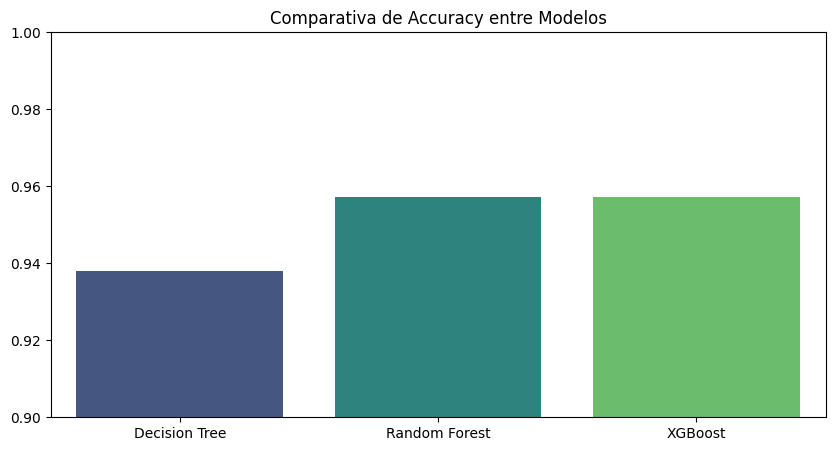

In [ ]:
models = ['Decision Tree', 'Random Forest', 'XGBoost']
scores = [accuracy_score(y_test, dt_model.predict(X_test)),
          accuracy_score(y_test, rf_model.predict(X_test)),
          accuracy_score(y_test, xgb_model.predict(X_test))]

plt.figure(figsize=(10, 5))
sns.barplot(x=models, y=scores, palette='viridis')
plt.title('Comparativa de Accuracy entre Modelos')
plt.ylim(0.9, 1.0)
plt.show()

Impacto de los datos faltantes: Al ser solo 16 de 699 (aprox. 2%), la imputación por mediana mantiene la integridad estadística sin perder registros valiosos de tumores malignos.

Árbol Simple vs. Ensamble: El árbol simple es altamente interpretable (podemos visualizarlo con plot_tree), pero tiende al overfitting. Random Forest reduce la varianza promediando múltiples árboles, mientras que XGBoost suele dar la mayor precisión al aprender de los errores de los árboles anteriores.

Interpretabilidad Médica: En este problema, atributos como bare_nuclei y uniformity_cell_size suelen aparecer en los niveles superiores del árbol, lo que coincide con los criterios clínicos de diagnóstico.

#Conclusión

Tras completar el análisis, se concluye que el preprocesamiento (específicamente la imputación de valores faltantes mediante la mediana) fue fundamental para mantener la integridad del dataset sin sesgar los resultados. Al comparar las arquitecturas, observamos que si bien el Árbol de Decisión es útil por su interpretabilidad, el Random Forest y el XGBoost ofrecen la robustez necesaria para un diagnóstico médico, logrando una precisión superior gracias a su capacidad de generalización y reducción del error. En última instancia, este laboratorio demuestra que el uso de modelos de ensamble no solo optimiza la detección de tumores malignos, sino que se consolida como una herramienta de apoyo clínico confiable para la toma de decisiones críticas.

#Referencias Bibliográficas

- Breiman, L. (2001). Random Forests. Machine Learning, 45(1), 5-32.https://link.springer.com/article/10.1023/A:1010933404324

Esta es la fuente primaria y obligatoria para entender el algoritmo de Random Forest y el concepto de Bagging.

- Chen, T., & Guestrin, C. (2016). XGBoost: A Scalable Tree Boosting System. En Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining (pp. 785–794). ACM. https://dl.acm.org/doi/epdf/10.1145/2939672.2939785

El artículo original que introdujo XGBoost, explicando la regularización y el manejo de datos faltantes que implementamos.

- Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, E. (2011). Scikit-learn: Machine Learning in Python. Journal of Machine Learning Research, 12, 2825–2830.

Referencia técnica para el uso de DecisionTreeClassifier y RandomForestClassifier dentro del ecosistema de Python.

<hr/>
<footer style="text-align:center; font-size:12px; color:gray;">
© 2026 UNAM Facultado de Ciencias – Todos los derechos reservados

</footer>